# The Same Agent — Three Ways
## `AgentExecutor` (legacy)  ·  `create_agent` (LangChain 1.0)  ·  `create_react_agent` (LangGraph)

**Module — Agentic AI · Side-by-Side Implementation**  
**Nunnari Academy — Generative AI & Agentic AI Program**

---

We build the **exact same agent three times** — a small calculator with `add`, `multiply`, `divide` — and compare how the loop is constructed at each level of abstraction.

| | `AgentExecutor` (legacy) | `create_agent` (LangChain 1.0) | `create_react_agent` (LangGraph) |
|---|---|---|---|
| Import path | `langchain.agents` | `langchain.agents` | `langgraph.prebuilt` |
| Builder | `create_tool_calling_agent` + `AgentExecutor` | `create_agent(model, tools, system_prompt=...)` | `create_react_agent(model, tools=...)` |
| Built on | Custom loop (pre-LangGraph) | LangGraph (under the hood) | LangGraph |
| Loop control | Hidden inside `.invoke()` | Hidden, but extensible via **middleware** | Explicit graph you can inspect/replace |
| Customization | Subclass `AgentExecutor` | `@dynamic_prompt`, `@wrap_model_call`, `@wrap_tool_call` | Swap nodes / edges directly |
| Streaming, checkpointing | Manual | Built in (inherited from LangGraph) | Built in |
| Status (Apr 2026) | Legacy — don't start here | **Recommended default** for tool-calling agents | Use when you outgrow the ReAct loop |

**All three produce the same answer.** The difference is *what you can build around the agent* — and how cleanly. `create_agent` is now the modern default; `create_react_agent` and hand-rolled `StateGraph`s are the path when you need full graph control.

## 1. Setup

In [1]:
# !pip install -q langchain langchain-openai langgraph python-dotenv

In [3]:
!pip install -U "langchain>=1.0" "langchain-core>=1.0" "langchain-openai>=1.0" "langgraph>=1.0"


  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.0 MB/s eta 0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2
  Attempting uninstall: jiter
    Found existing installation: jiter 0.8.2
    Uninstalling jiter-0.8.2:
      Successfully uninstalled jiter-0.8.2
  Attempting uninstall: openai
    Found existing installation: openai 1.64.0
    Uninstalling openai-1.64.0:
      Successfully uninstalled openai-1.64.0
  Attempting uninstall: langchain-openai
    Found existing installation: langchain-openai 0.3.1
    Uninstalling langchain-openai-0.3.1:
      Successfully uninstalled langchain-openai-0.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that

In [1]:
!pip show typing_extensions


Name: typing_extensions
Version: 4.15.0
Summary: Backported and Experimental Type Hints for Python 3.9+
Home-page: 
Author: 
Author-email: "Guido van Rossum, Jukka Lehtosalo, Łukasz Langa, Michael Lee" <levkivskyi@gmail.com>
License-Expression: PSF-2.0
Location: /Users/navaneethmalingan/.pyenv/versions/3.13.1/lib/python3.13/site-packages
Requires: 
Required-by: anthropic, beautifulsoup4, chromadb, fastapi, huggingface_hub, langchain-core, langchain-protocol, openai, opentelemetry-sdk, pydantic, pydantic_core, pyee, SQLAlchemy, typer, typing-inspect, typing-inspection


In [3]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

load_dotenv()
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not found."

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("Setup complete.")

Setup complete.


## 2. Shared Tools

We define three tools once and use them in both implementations. The `@tool` decorator works the same way for both libraries — that's actually the point: tools are portable; only the orchestration differs.

In [4]:
@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b

@tool
def divide(a: float, b: float) -> float:
    """Divide a by b."""
    return a / b

tools = [add, multiply, divide]
QUESTION = "Compute (24 + 6) * 5, then divide that by 3. Show me the final number."
print("3 tools defined. Test question:", QUESTION)

3 tools defined. Test question: Compute (24 + 6) * 5, then divide that by 3. Show me the final number.


## 3. The LangChain Way — `AgentExecutor`

The classic LangChain agent has three pieces:

1. A **prompt** with a `{messages}` and `{agent_scratchpad}` placeholder (where the tool calls/results get stitched in).
2. An **agent** built from `create_tool_calling_agent(llm, tools, prompt)` — this is the *brain*: it decides which tool to call.
3. An **AgentExecutor** that wraps the brain and runs the loop: call agent → execute tool → feed result back → repeat until no more tool calls.

You don't see the loop — `AgentExecutor` hides it. You just call `.invoke({"input": ...})` and get the final answer.

In [6]:
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate

lc_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a careful math assistant. Use tools for every arithmetic step."),
    ("human",  "{input}"),
    ("placeholder", "{agent_scratchpad}"),  # AgentExecutor fills this with tool I/O
])

lc_agent = create_tool_calling_agent(llm, tools, lc_prompt)
lc_executor = AgentExecutor(agent=lc_agent, tools=tools, verbose=True)

lc_result = lc_executor.invoke({"input": QUESTION})
print("\nFinal answer:", lc_result["output"])

ImportError: cannot import name 'AgentExecutor' from 'langchain.agents' (/Users/navaneethmalingan/.pyenv/versions/3.13.1/lib/python3.13/site-packages/langchain/agents/__init__.py)

**Notes on the output above.** With `verbose=True` you can see the loop LangChain ran for you:

1. LLM called `add(24, 6)` → `30`
2. LLM called `multiply(30, 5)` → `150`
3. LLM called `divide(150, 3)` → `50.0`
4. LLM stopped calling tools and produced the final text.

That loop lives inside `AgentExecutor.invoke`. You can't easily pause between steps, branch, or persist mid-run.

## 4. The Modern LangChain Way — `create_agent` (1.0)

In late 2025 / early 2026, LangChain shipped a new agent factory in `langchain.agents` called `create_agent`. It is the **opinionated successor to `AgentExecutor`** and is internally implemented on top of LangGraph — so you get the explicit graph, streaming, and checkpointing for free, behind a one-line API.

Compared to `AgentExecutor`:
- No `{agent_scratchpad}` template — `system_prompt` is just a string kwarg.
- Built-in **middleware** hooks (`@dynamic_prompt`, `@wrap_model_call`, `@wrap_tool_call`, ...) for clean extension instead of subclassing.
- Same `.invoke` / `.stream` interface as any LangGraph graph (because that is what it is under the hood).

In [ ]:
from langchain.agents import create_agent

ca_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a careful math assistant. Use tools for every arithmetic step.",
)

ca_result = ca_agent.invoke(
    {"messages": [{"role": "user", "content": QUESTION}]}
)
print("Final answer:", ca_result["messages"][-1].content)

ImportError: cannot import name 'create_agent' from 'langchain.agents' (/Users/navaneethmalingan/.pyenv/versions/3.13.1/lib/python3.13/site-packages/langchain/agents/__init__.py)

### 4.1 Middleware — clean hooks for customization

Middleware is the headline feature of `create_agent`. Instead of subclassing or rebuilding the loop, you decorate small functions that run at well-defined points in the agent lifecycle.

Below, `@wrap_tool_call` intercepts every tool execution to log the call and result — the kind of cross-cutting concern that was awkward in `AgentExecutor`. Other built-in hooks include `@dynamic_prompt`, `@wrap_model_call`, `@before_model`, and `@after_model`.

In [ ]:
from langchain.agents.middleware import wrap_tool_call

@wrap_tool_call
def log_tool_calls(request, handler):
    name = request.tool_call["name"]
    args = request.tool_call["args"]
    print(f"  [middleware] -> {name}({args})")
    response = handler(request)
    print(f"  [middleware] <- {response.content}")
    return response

ca_logged = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a careful math assistant.",
    middleware=[log_tool_calls],
)

logged_result = ca_logged.invoke(
    {"messages": [{"role": "user", "content": QUESTION}]}
)
print("\nFinal answer:", logged_result["messages"][-1].content)

## 5. The LangGraph Way — `create_react_agent`

For full control of the agent loop, drop down to LangGraph directly. `create_react_agent` (from `langgraph.prebuilt`) wires the same two-node graph (`agent` ↔ `tools`) but exposes it as a graph object you can inspect, modify, or replace node-by-node.

`create_agent` from section 4 is built on top of this — so anything you see below (visualization, streaming, checkpointing) also works on the `create_agent` instance. The reason to come down to this layer is when you need to:
- visualize the exact graph you're running
- swap nodes in/out (custom pre-processing, custom tool execution, etc.)
- build non-ReAct topologies (routing, orchestrator-worker, evaluator-optimizer)

In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage, SystemMessage

lg_agent = create_react_agent(llm, tools=tools)

lg_result = lg_agent.invoke({
    "messages": [
        SystemMessage("You are a careful math assistant. Use tools for every arithmetic step."),
        HumanMessage(QUESTION),
    ]
})

for m in lg_result["messages"]:
    m.pretty_print()

================================ System Message ================================

You are a careful math assistant. Use tools for every arithmetic step.
================================ Human Message =================================

Compute (24 + 6) * 5, then divide that by 3. Show me the final number.
================================== Ai Message ==================================
Tool Calls:
  add (call_rjBDLACAty9g5o1CNFWWsjuh)
 Call ID: call_rjBDLACAty9g5o1CNFWWsjuh
  Args:
    a: 24
    b: 6
  multiply (call_OfSRQpPRUYbj4c4xlqxQinbY)
 Call ID: call_OfSRQpPRUYbj4c4xlqxQinbY
  Args:
    a: 30
    b: 5
================================= Tool Message =================================
Name: add

30.0
================================= Tool Message =================================
Name: multiply

150.0
================================== Ai Message ==================================
Tool Calls:
  divide (call_99yv11KkDSMobenrGcaSznQl)
 Call ID: call_99yv11KkDSMobenrGcaSznQl
  Args:
    

### 5.1 Free upgrade #1 — Visualize the graph

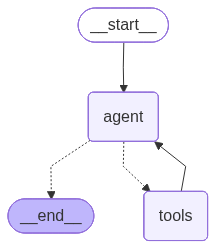

In [ ]:
from IPython.display import Image, display

try:
    display(Image(lg_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(lg_agent.get_graph().draw_mermaid())

### 5.2 Free upgrade #2 — Stream every step

With LangChain's `AgentExecutor` you mostly see input → output. With LangGraph you can stream the *intermediate* state of the graph — every node update.

In [ ]:
for step, payload in enumerate(lg_agent.stream(
    {"messages": [HumanMessage(QUESTION)]},
    stream_mode="updates",
), start=1):
    for node_name, node_state in payload.items():
        msg = node_state["messages"][-1]
        kind = type(msg).__name__
        preview = (msg.content or "").strip().replace("\n", " ")[:120]
        tool_info = ""
        if getattr(msg, "tool_calls", None):
            tool_info = f" -> calls {[c['name'] for c in msg.tool_calls]}"
        print(f"step {step}  [{node_name}] {kind}{tool_info}: {preview}")

step 1  [agent] AIMessage -> calls ['add', 'multiply']: 
step 2  [tools] ToolMessage: 150.0
step 3  [agent] AIMessage -> calls ['divide']: 
step 4  [tools] ToolMessage: 50.0
step 5  [agent] AIMessage: The final result of \((24 + 6) * 5\) divided by 3 is \(50\).


### 5.3 Free upgrade #3 — Per-thread memory in one extra line

Add a `checkpointer` and the agent remembers prior turns within a `thread_id`. Same agent, just compiled with persistence.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory_agent = create_react_agent(llm, tools=tools, checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "user-42"}}

# Turn 1
r1 = memory_agent.invoke(
    {"messages": [HumanMessage("What is 8 multiplied by 9?")]}, config
)
print("Turn 1:", r1["messages"][-1].content)

# Turn 2 — references the previous answer; agent recalls 72
r2 = memory_agent.invoke(
    {"messages": [HumanMessage("Now add 100 to that result.")]}, config
)
print("Turn 2:", r2["messages"][-1].content)

Turn 1: 8 multiplied by 9 is 72.
Turn 2: Adding 100 to 72 gives you 172.


## 6. Side-by-Side Comparison

| Aspect | `AgentExecutor` (legacy) | `create_agent` (LangChain 1.0) | `create_react_agent` (LangGraph) |
|---|---|---|---|
| **Lines to a working agent** | ~6 (prompt + agent + executor) | ~3 | ~1 |
| **Prompt scaffolding** | `{agent_scratchpad}` placeholder required | `system_prompt=` kwarg | Plain messages list |
| **Loop visibility** | Hidden behind `.invoke()` | Hidden, but middleware can hook each step | Explicit graph, fully inspectable |
| **Customization model** | Subclass `AgentExecutor` | Decorator middleware (`@wrap_tool_call`, `@dynamic_prompt`, ...) | Replace nodes / edges directly |
| **Streaming intermediate state** | Limited | First-class (inherited from LangGraph) | First-class (`.stream(stream_mode=...)`) |
| **Memory across turns** | DIY with `RunnableWithMessageHistory` | `checkpointer=MemorySaver()` | `checkpointer=MemorySaver()` |
| **Structured output** | Manual parsing | `response_format=ToolStrategy(...)` / `ProviderStrategy(...)` | Manual / via tool-calling |
| **Status (Apr 2026)** | Legacy, still supported | **Modern default** | Use when you need full graph control |

### When to pick which?

- **Existing `AgentExecutor` code** → migrate to `create_agent` when you next touch it. The API is cleaner and you stop being on the legacy path.
- **New tool-calling agent** → start with `create_agent`. It is the LangChain 1.0 default and gives you LangGraph's runtime (streaming, checkpointing, middleware) without writing graph code.
- **Non-ReAct topology** (routing, orchestrator-worker, evaluator-optimizer, multi-agent handoffs, human-in-the-loop) → drop down to LangGraph and build a `StateGraph` yourself. `create_react_agent` is the prebuilt for the simple ReAct case; everything else is a small rearrangement of the same primitives.

### The deeper point

`create_agent` and `create_react_agent` are both just **graphs with a `tools_condition` edge** — exactly the hand-rolled agent in the *Workflows and Agents* notebook. LangChain 1.0 didn't introduce a new kind of agent; it gave the LangGraph-based ReAct loop a clean, opinionated factory with middleware so you don't have to build it yourself. Once you see that, every other agentic pattern becomes a small rearrangement of the same nodes and edges.